In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
from scipy import stats
import utils
import seaborn as sns
import pingouin as pg
import matplotlib.cm as cm

import statsmodels.stats.power as smp
from statsmodels.stats.anova import AnovaRM
from tqdm import tqdm


from natsort import index_natsorted

# plt.rcParams['font.family'] = 'Times New Roman'
# plt.rcParams['font.family'] = 'Calibri'

path_figs = "./Figs/"

seq_length = 11 #Length of sequences

fingers = ['1', '2', '3', '4', '5'] #mapping of fingers to numbers

iti = 3000   #Inter trial interval
hand = 2 #left or right hand

sub_nums = [6, 7, 8]
g_sequences = {}
# g_sequences[0] = ['13524232514' ,'35421252143',  '51423252413', '14325242135'] #Group 1 sequences
# g_sequences[1] = ['51423252413', '14325242135', '13524232514' ,'35421252143'] #Group 2 sequences

g_sequences[0] = ['13524232514' ,'54231251343',  '15423241351', '42531451342'] #Group 1 sequences
g_sequences[1] = ['15423241351', '42531451342', '13524232514' ,'54231251343'] #Group 2 sequences

# total_sub_num = 38
num_sessions = 1
num_blocks_per_session = 12
num_baseline_blocks = 1


In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker

def set_figure_style(scale="1col"):
    """
    Set figure styling based on publication constraints.
    
    Parameters:
        scale (str): Scale of the figure, choose from "1col", "1.5col", "2col".
                     - "1col" for 8.5cm
                     - "1.5col" for 11.6cm
                     - "2col" for 17.6cm
    """
    # Define width options in cm
    widths = {"1col": 7.62, "1.5col": 11.6, "2col": 16.5}
    
    if scale not in widths:
        raise ValueError("Invalid scale. Choose from '1col', '1.5col', or '2col'.")
    
    # Convert width from cm to inches (1 cm = 0.393701 inches)
    width_in = widths[scale] * 0.393701
    
    # Set figure size (width, height)
    # Assuming height proportional to width (Golden Ratio)
    golden_ratio = (5**0.5 - 1) / 2
    rcParams["figure.figsize"] = (width_in, width_in * golden_ratio)
    
    # Set font sizes
    rcParams["font.size"] = 10  # General font size
    rcParams["axes.titlesize"] = 12  # Figure title
    rcParams["axes.labelsize"] = 9  # Axis main label
    rcParams["xtick.labelsize"] = 7  # Tick labels
    rcParams["ytick.labelsize"] = 7
    rcParams["legend.fontsize"] = 8  # Legend entries
    rcParams["figure.titleweight"] = "bold"
    
    # Set stroke width
    rcParams["axes.linewidth"] = 0.75
    rcParams["xtick.major.width"] = 0.75
    rcParams["ytick.major.width"] = 0.75

    
    # Subpanel lettering size
    rcParams["text.usetex"] = False  # Set to True if using LaTeX
    rcParams["axes.formatter.use_mathtext"] = True  # Math text for scientific notation

def add_subpanel_label(ax, label, fontsize=20, position=(-0.1, 1.05)):
    """
    Add a subpanel label (e.g., 'a', 'b') to a subplot.
    
    Parameters:
        ax (Axes): Matplotlib Axes object.
        label (str): The label text.
        fontsize (int): Font size for the label.
        position (tuple): Position of the label in axes coordinates.
    """
    ax.text(position[0], position[1], label, transform=ax.transAxes, 
            fontsize=fontsize, fontweight="bold", va="top", ha="left")

###
set_figure_style(scale="1col")

sns.color_palette('colorblind')


[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [3]:
# reload utils
import importlib
importlib.reload(utils)

<module 'utils' from '/Users/amin/projects/SeqFingerSpeech/utils.py'>

In [4]:
subjs_list = utils.read_dat_files_subjs_list_speech(sub_nums)

for subj in subjs_list: ###Adding IPIs
    utils.add_IPI(subj)


subjs = pd.concat(subjs_list) ###Merging all subjs into one dataframe
# exclude first familiarization block
subjs = subjs[subjs['BN'] != 1]
subjs['isTrainSeq'] = subjs.apply(utils.add_trained_transfer_untrained_flag, axis=1)
subjs['effector+isTrain'] = subjs['effector'].astype(str) + '_' + subjs['isTrainSeq'].astype(str)
subjs['isPrePostTrain'] = subjs.apply(utils.add_pre_train_post_flag, axis=1)
subjs.reset_index(inplace=True, drop=True)
subjs['count'] = 1

In [5]:
subjs

,BN,TN,SubNum,group,effector,isTrain,cue,press1,press2,press3,...,IPI5,IPI6,IPI7,IPI8,IPI9,IPI10,isTrainSeq,effector+isTrain,isPrePostTrain,count
0,2,1,6,1,0,0,42531451342,4,2,5,...,0,0,0,0,0,0,transfer,0_transfer,pre-test,1
1,2,2,6,1,0,0,13524232514,1,3,5,...,0,0,0,0,0,0,untrained,0_untrained,pre-test,1
2,2,3,6,1,0,0,15423241351,1,5,4,...,0,0,0,0,0,0,trained,0_trained,pre-test,1
3,2,4,6,1,0,0,15423241351,1,5,4,...,0,0,0,0,0,0,trained,0_trained,pre-test,1
4,2,5,6,1,0,0,42531451342,4,2,5,...,0,0,0,0,0,0,transfer,0_transfer,pre-test,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1115,13,28,8,1,2,0,13524232514,1,3,5,...,210,195,210,295,230,235,untrained,2_untrained,post-test,1
1116,13,29,8,1,0,0,15423241351,1,5,4,...,0,0,0,0,0,0,trained,0_trained,post-test,1
1117,13,30,8,1,0,0,42531451342,4,2,5,...,0,0,0,0,0,0,transfer,0_transfer,post-test,1
1118,13,31,8,1,0,0,13524232514,1,3,5,...,0,0,0,0,0,0,untrained,0_untrained,post-test,1


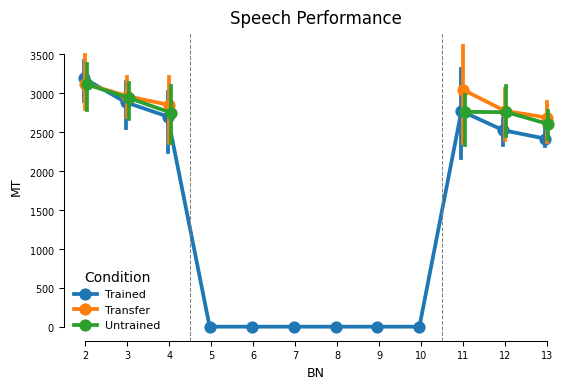

In [6]:
set_figure_style(scale="2col")

subjs_correct = subjs[subjs['isError'] == 0]
subjs_grouped = subjs_correct.groupby(['BN', 'SubNum', 'effector+isTrain', 'effector']).agg({
    'MT': 'median',
    'count': 'sum'
}).reset_index()

# effector = finger (2)
subjs_grouped = subjs_grouped[subjs_grouped['effector'] == 0]

hue_order = ['0_trained', '0_transfer', '0_untrained']
label_map = {
    '0_trained': 'Trained',
    '0_untrained': 'Untrained',
    '0_transfer': 'Transfer'
}

ax = sns.pointplot(
    data=subjs_grouped,
    x='BN', y='MT',
    hue='effector+isTrain',
    hue_order=hue_order,
    dodge=True
)

plt.axvline(x=2.5, color='gray', linestyle='--', linewidth=0.75)
plt.axvline(x=8.5, color='gray', linestyle='--', linewidth=0.75)


handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    [label_map.get(l, l) for l in labels],
    title='Condition',
    frameon=False
)

plt.title('Speech Performance')
sns.despine(trim=True)


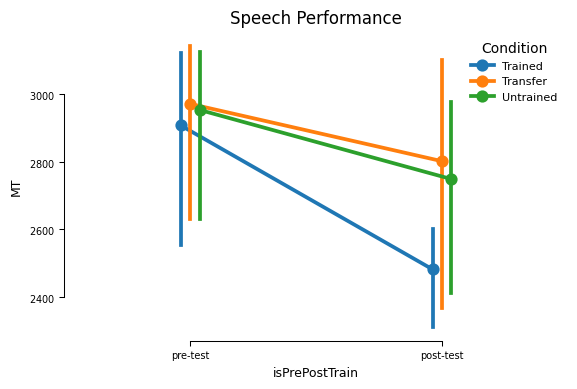

In [7]:
set_figure_style(scale="2col")

subjs_correct = subjs[subjs['isError'] == 0]
subjs_grouped = subjs_correct.groupby(['isPrePostTrain', 'SubNum', 'effector+isTrain', 'effector']).agg({
    'MT': 'median',
    'count': 'sum'
}).reset_index()

subjs_grouped = subjs_grouped[subjs_grouped['isPrePostTrain'] != 'train']
subjs_grouped = subjs_grouped[subjs_grouped['effector'] == 0]

subjs_grouped['isPrePostTrain'] = pd.Categorical(
    subjs_grouped['isPrePostTrain'],
    categories=['pre-test', 'post-test'],
    ordered=True
)

hue_order = ['0_trained', '0_transfer', '0_untrained']
label_map = {
    '0_trained': 'Trained',
    '0_transfer': 'Transfer',
    '0_untrained': 'Untrained'
}

ax = sns.pointplot(
    data=subjs_grouped,
    x='isPrePostTrain',
    y='MT',
    hue='effector+isTrain',
    hue_order=hue_order,
    dodge=True
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=[label_map.get(l, l) for l in labels],
    title='Condition',
    frameon=False
)
plt.title('Speech Performance')
sns.despine(trim=True)


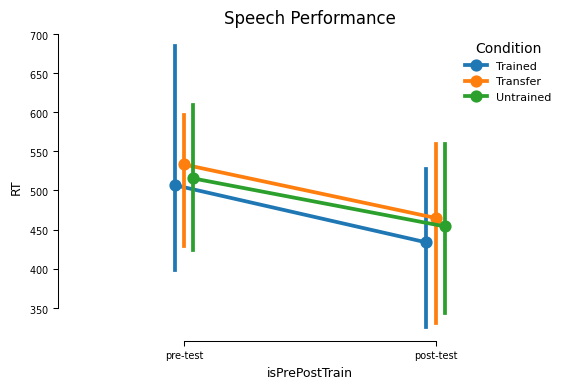

In [8]:
set_figure_style(scale="2col")

subjs_correct = subjs[subjs['isError'] == 0]
subjs_grouped = subjs_correct.groupby(['isPrePostTrain', 'SubNum', 'effector+isTrain', 'effector']).agg({
    'RT': 'median',
    'count': 'sum'
}).reset_index()

subjs_grouped = subjs_grouped[subjs_grouped['isPrePostTrain'] != 'train']
subjs_grouped = subjs_grouped[subjs_grouped['effector'] == 0]

subjs_grouped['isPrePostTrain'] = pd.Categorical(
    subjs_grouped['isPrePostTrain'],
    categories=['pre-test', 'post-test'],
    ordered=True
)

hue_order = ['0_trained', '0_transfer', '0_untrained']
label_map = {
    '0_trained': 'Trained',
    '0_transfer': 'Transfer',
    '0_untrained': 'Untrained'
}

ax = sns.pointplot(
    data=subjs_grouped,
    x='isPrePostTrain',
    y='RT',
    hue='effector+isTrain',
    hue_order=hue_order,
    dodge=True
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=[label_map.get(l, l) for l in labels],
    title='Condition',
    frameon=False
)
plt.title('Speech Performance')
sns.despine(trim=True)


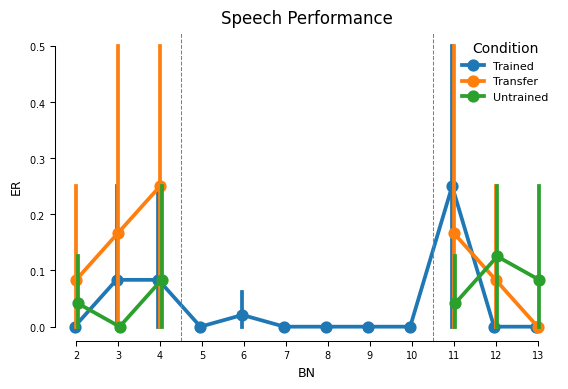

In [9]:
set_figure_style(scale="2col")

# subjs_correct = subjs[subjs['isError'] == 0]
subjs_grouped = subjs.groupby(['BN', 'SubNum', 'effector+isTrain', 'effector']).agg({
    'isError': 'sum',
    'count': 'sum'
}).reset_index()

# effector = finger (2)
subjs_grouped = subjs_grouped[subjs_grouped['effector'] == 0]
subjs_grouped['ER'] = subjs_grouped['isError'] / subjs_grouped['count']

hue_order = ['0_trained', '0_transfer', '0_untrained']
label_map = {
    '0_trained': 'Trained',
    '0_untrained': 'Untrained',
    '0_transfer': 'Transfer'
}

ax = sns.pointplot(
    data=subjs_grouped,
    x='BN', y='ER',
    hue='effector+isTrain',
    hue_order=hue_order,
    dodge=True
)

plt.axvline(x=2.5, color='gray', linestyle='--', linewidth=0.75)
plt.axvline(x=8.5, color='gray', linestyle='--', linewidth=0.75)


handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    [label_map.get(l, l) for l in labels],
    title='Condition',
    frameon=False
)

plt.title('Speech Performance')
sns.despine(trim=True)
